In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [2]:
#Device + Hyperparameters
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 15
INPUT_SIZE = 28 * 28
NUM_CLASSES = 10

Using device: cuda


In [3]:
#Data Preprocessing + Load Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Dataset loaded successfully")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.7MB/s]

Dataset loaded successfully


In [4]:
#Split Data + DataLoaders
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

print("Data loaders ready")

Data loaders ready


In [5]:
#Build MLP Model
class MLP(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()

        if activation == 'relu':
            act = nn.ReLU()
        elif activation == 'sigmoid':
            act = nn.Sigmoid()
        else:
            raise ValueError("Choose relu or sigmoid")

        self.model = nn.Sequential(
            nn.Linear(INPUT_SIZE, 128),
            nn.BatchNorm1d(128),
            act,
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            act,
            nn.Dropout(0.2),

            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        x = x.view(-1, INPUT_SIZE)
        return self.model(x)

print("Model class created")

Model class created


In [6]:
#Training Function
def train_model(activation_name):

    print(f"\nTraining with {activation_name.upper()} activation")

    model = MLP(activation=activation_name).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(EPOCHS):

        # Training
        model.train()
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        preds = []
        truths = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                preds.extend(predicted.cpu().numpy())
                truths.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(truths, preds)

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, train_losses, val_losses, val_accuracies

In [7]:
#Experiment 1 (ReLU)
relu_model, relu_train_loss, relu_val_loss, relu_acc = train_model('relu')


Training with RELU activation
Epoch 1/15 | Train Loss: 0.6205 | Val Loss: 0.3791 | Val Acc: 0.8631
Epoch 2/15 | Train Loss: 0.4440 | Val Loss: 0.3556 | Val Acc: 0.8694
Epoch 3/15 | Train Loss: 0.4065 | Val Loss: 0.3395 | Val Acc: 0.8758
Epoch 4/15 | Train Loss: 0.3818 | Val Loss: 0.3135 | Val Acc: 0.8854
Epoch 5/15 | Train Loss: 0.3617 | Val Loss: 0.3167 | Val Acc: 0.8822
Epoch 6/15 | Train Loss: 0.3528 | Val Loss: 0.3079 | Val Acc: 0.8845
Epoch 7/15 | Train Loss: 0.3405 | Val Loss: 0.2985 | Val Acc: 0.8902
Epoch 8/15 | Train Loss: 0.3313 | Val Loss: 0.2991 | Val Acc: 0.8882
Epoch 9/15 | Train Loss: 0.3243 | Val Loss: 0.2958 | Val Acc: 0.8932
Epoch 10/15 | Train Loss: 0.3156 | Val Loss: 0.2909 | Val Acc: 0.8944
Epoch 11/15 | Train Loss: 0.3057 | Val Loss: 0.2852 | Val Acc: 0.8951
Epoch 12/15 | Train Loss: 0.3023 | Val Loss: 0.2921 | Val Acc: 0.8931
Epoch 13/15 | Train Loss: 0.2986 | Val Loss: 0.2859 | Val Acc: 0.8968
Epoch 14/15 | Train Loss: 0.2879 | Val Loss: 0.2871 | Val Acc: 0.894

In [8]:
#Experiment 2 (Sigmoid)
sig_model, sig_train_loss, sig_val_loss, sig_acc = train_model('sigmoid')


Training with SIGMOID activation
Epoch 1/15 | Train Loss: 0.9921 | Val Loss: 0.5094 | Val Acc: 0.8354
Epoch 2/15 | Train Loss: 0.5711 | Val Loss: 0.4244 | Val Acc: 0.8461
Epoch 3/15 | Train Loss: 0.5085 | Val Loss: 0.4136 | Val Acc: 0.8512
Epoch 4/15 | Train Loss: 0.4778 | Val Loss: 0.3752 | Val Acc: 0.8678
Epoch 5/15 | Train Loss: 0.4517 | Val Loss: 0.3716 | Val Acc: 0.8685
Epoch 6/15 | Train Loss: 0.4303 | Val Loss: 0.3577 | Val Acc: 0.8732
Epoch 7/15 | Train Loss: 0.4156 | Val Loss: 0.3478 | Val Acc: 0.8747
Epoch 8/15 | Train Loss: 0.4028 | Val Loss: 0.3448 | Val Acc: 0.8743
Epoch 9/15 | Train Loss: 0.3909 | Val Loss: 0.3361 | Val Acc: 0.8824
Epoch 10/15 | Train Loss: 0.3775 | Val Loss: 0.3311 | Val Acc: 0.8820
Epoch 11/15 | Train Loss: 0.3717 | Val Loss: 0.3308 | Val Acc: 0.8822
Epoch 12/15 | Train Loss: 0.3618 | Val Loss: 0.3167 | Val Acc: 0.8881
Epoch 13/15 | Train Loss: 0.3562 | Val Loss: 0.3148 | Val Acc: 0.8860
Epoch 14/15 | Train Loss: 0.3484 | Val Loss: 0.3146 | Val Acc: 0.

In [9]:
#Evaluation Function
def evaluate(model):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    test_loss = 0
    preds = []
    truths = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            truths.extend(labels.cpu().numpy())

    avg_loss = test_loss / len(test_loader)
    acc = accuracy_score(truths, preds)

    return avg_loss, acc

In [10]:
#Final Results
relu_test_loss, relu_test_acc = evaluate(relu_model)
sig_test_loss, sig_test_acc = evaluate(sig_model)

print("\n========== FINAL RESULTS ==========")
print(f"ReLU    : Test Loss: {relu_test_loss:.4f} | Test Accuracy: {relu_test_acc:.4f}")
print(f"Sigmoid : Test Loss: {sig_test_loss:.4f} | Test Accuracy: {sig_test_acc:.4f}")


========== FINAL RESULTS ==========
ReLU    : Test Loss: 0.3203 | Test Accuracy: 0.8847
Sigmoid : Test Loss: 0.3512 | Test Accuracy: 0.8717


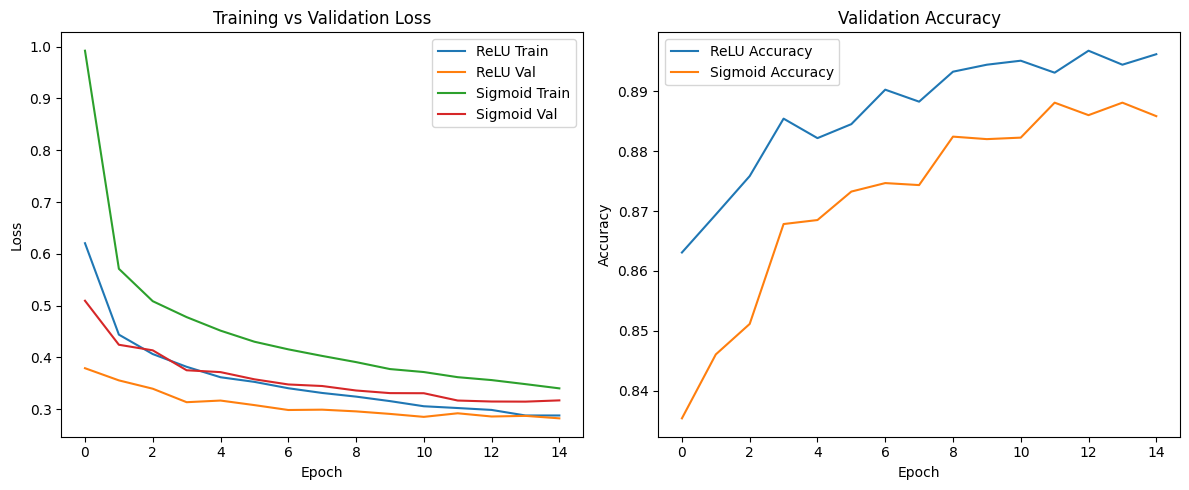

Project completed successfully


In [11]:
#Visualization
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(relu_train_loss, label='ReLU Train')
plt.plot(relu_val_loss, label='ReLU Val')
plt.plot(sig_train_loss, label='Sigmoid Train')
plt.plot(sig_val_loss, label='Sigmoid Val')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(relu_acc, label='ReLU Accuracy')
plt.plot(sig_acc, label='Sigmoid Accuracy')

plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig("results.png")
plt.show()

print("Project completed successfully")